# IMDb Movies — Exploratory Data Analysis & Insights

**Project type:** End-to-end Exploratory Data Analysis (EDA)  
**Dataset:** `movies_dataset.csv`  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Objective
Analyze movie metadata and IMDb performance to understand:
- Which genres and years dominate the dataset?
- What movie runtimes and ratings look like?
- Which genres receive stronger IMDb ratings?
- How IMDb ratings relate to votes and Metascore?
- Which directors appear most frequently?
- How movie production and audience response vary over time?
- What data-quality issues must be addressed before analysis?

> **Important:** This notebook is intentionally self-contained. The original notebook mixed the movie dataset with an unrelated roller-coaster dataset, which caused schema inconsistencies and a `KeyError`. This rewritten version keeps one dataset and one analysis pipeline throughout.


## 1. Analytical Questions

1. What is the overall structure and quality of the movie dataset?
2. How many movies are represented by year?
3. Which genres are most common?
4. What are the distributions of runtime and IMDb rating?
5. Which genres have the highest average IMDb rating?
6. Do longer movies receive higher or lower IMDb ratings?
7. Is IMDb rating associated with the number of votes?
8. How closely does IMDb rating align with Metascore?
9. Which directors have the most movies in the dataset?
10. Which directors have the highest average IMDb rating, subject to a minimum movie count?
11. How has the average IMDb rating changed over time?
12. How has the number of movies in the dataset changed over time?
13. Which countries contribute the most movies?
14. Which languages are most represented?
15. Which content ratings are most common?
16. What are the highest-rated movies after applying a vote threshold?
17. What are the most commercially visible movies using available BoxOffice data?
18. What actionable insights can be communicated to a stakeholder?


## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Load the Dataset

In [2]:
DATA_PATH = Path("movies_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Place movies_dataset.csv in the same folder as this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")
display(df_raw.head())


Rows: 594
Columns: 20


,Title,Year,Rated,Released,Runtime(in minutes),Genre,Director,Writer,Actors,Plot,Language,Country,Awards,Ratings,Metascore,imdbRating,imdbVotes,imdbID,Type,BoxOffice
0,12th Fail,2023,NaN,27 Oct 2023,147,"Biography, Drama",Vidhu Vinod Chopra,"Vidhu Vinod Chopra, Jaskunwar Kohli, Anurag Pa...","Vikrant Massey, Medha Shankr, Anant Joshi",The real-life story of IPS Officer Manoj Kumar...,"Hindi, English",India,31 wins & 40 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.70,"158,786",tt23849204,movie,NaN
1,3 Idiots,2009,PG-13,25 Dec 2009,170,"Comedy, Drama",Rajkumar Hirani,"Abhijat Joshi, Rajkumar Hirani, Vidhu Vinod Ch...","Aamir Khan, Madhavan, Mona Singh",Two friends are searching for their long lost ...,"Hindi, English",India,64 wins & 30 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",67.00,8.40,"474,710",tt1187043,movie,"$6,532,874"
2,Andhadhun,2018,Not Rated,05 Oct 2018,139,"Crime, Mystery, Thriller",Sriram Raghavan,"Arijit Biswas, Yogesh Chandekar, Sriram Raghavan","Ayushmann Khurrana, Tabu, Radhika Apte",A series of mysterious events change the life ...,"Hindi, English",India,35 wins & 43 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.20,"112,972",tt8108198,movie,"$1,193,046"
3,Anand,1971,Not Rated,12 Mar 1971,122,"Drama, Musical",Hrishikesh Mukherjee,"Hrishikesh Mukherjee, Gulzar, D.N. Mukherjee","Rajesh Khanna, Amitabh Bachchan, Sumita Sanyal",The story of a terminally ill man who wishes t...,Hindi,India,9 wins & 1 nomination,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.10,"35,928",tt0066763,movie,NaN
4,Anbe Sivam,2003,Not Rated,14 Jan 2003,160,"Adventure, Comedy, Drama",Sundar C.,"Kamal Haasan, Madan, Mohan Nair","Kamal Haasan, Madhavan, Kiran Rathod","Two men, one young and arrogant, the other dam...","Tamil, Hindi",India,2 wins & 3 nominations,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.60,"25,583",tt0367495,movie,NaN


## 4. Data Understanding

The original file contains **594 rows and 20 columns**. Its main fields include title, year, release date, runtime, genre, director, language, country, IMDb rating, IMDb votes, Metascore, content rating, and BoxOffice.

The original notebook also showed that several columns were stored as strings even though they represent numeric/date values, notably `Released`, `imdbVotes`, and `BoxOffice`. 


In [3]:
print("Shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(df_raw.describe(include="all").T)


Shape: (594, 20)

Column names:
['Title', 'Year', 'Rated', 'Released', 'Runtime(in minutes)', 'Genre', 'Director', 'Writer', 'Actors', 'Plot', 'Language', 'Country', 'Awards', 'Ratings', 'Metascore', 'imdbRating', 'imdbVotes', 'imdbID', 'Type', 'BoxOffice']

Data types:


,dtype
Title,object
Year,int64
Rated,object
Released,object
Runtime(in minutes),int64
Genre,object
Director,object
Writer,object
Actors,object
Plot,object



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Title,594,594,12th Fail,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,594.00,NaN,NaN,NaN,"2,004.16",17.22,"1,941.00","1,999.00","2,009.00","2,016.75","2,026.00"
Rated,581,10,R,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Released,594,539,12 Oct 2012,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Runtime(in minutes),594.00,NaN,NaN,NaN,128.76,27.44,8.00,110.25,126.00,143.00,321.00
Genre,594,144,Drama,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,594,314,Steven Spielberg,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Writer,594,528,M. Night Shyamalan,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actors,594,589,"Mark Hamill, Harrison Ford, Carrie Fisher",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot,594,594,The real-life story of IPS Officer Manoj Kumar...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Cleaning

### Cleaning decisions
- Standardize column names.
- Remove exact duplicate rows.
- Parse release dates.
- Convert IMDb votes to numeric.
- Convert BoxOffice values such as `$6,532,874` to numeric.
- Convert numeric columns safely.
- Treat missing values according to their meaning instead of blindly filling every field.
- Keep missing `Metascore` and `BoxOffice` values as missing because absence of a value is not equivalent to zero.
- Remove rows only when essential analytical fields are unavailable for a specific analysis.

The source notebook identified missing values in `Rated`, `Metascore`, and `BoxOffice`; for example, it recorded 13 missing `Rated`, 84 missing `Metascore`, and 73 missing `BoxOffice` values. fileciteturn5file0L747-L768


In [4]:
df = df_raw.copy()

# Standardize column names without changing their meaning.
df.columns = [c.strip() for c in df.columns]

# Remove exact duplicates.
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Parse dates.
if "Released" in df.columns:
    df["Released"] = pd.to_datetime(df["Released"], errors="coerce")

# Numeric conversions.
for col in ["Year", "Runtime(in minutes)", "Metascore", "imdbRating"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "imdbVotes" in df.columns:
    df["imdbVotes"] = (
        df["imdbVotes"].astype("string")
        .str.replace(",", "", regex=False)
        .str.extract(r"(\d+)", expand=False)
    )
    df["imdbVotes"] = pd.to_numeric(df["imdbVotes"], errors="coerce")

if "BoxOffice" in df.columns:
    df["BoxOffice_USD"] = (
        df["BoxOffice"].astype("string")
        .str.replace(r"[$,]", "", regex=True)
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
    )
    df["BoxOffice_USD"] = pd.to_numeric(df["BoxOffice_USD"], errors="coerce")

# Feature engineering.
if "Released" in df.columns:
    df["Release_Year"] = df["Released"].dt.year
    df["Release_Decade"] = (df["Release_Year"] // 10 * 10).astype("Int64")

# Use Year where release year is unavailable.
if "Release_Year" in df.columns and "Year" in df.columns:
    df["Analysis_Year"] = df["Release_Year"].fillna(df["Year"])

# Runtime categories.
if "Runtime(in minutes)" in df.columns:
    df["Runtime_Category"] = pd.cut(
        df["Runtime(in minutes)"],
        bins=[0, 90, 120, 150, np.inf],
        labels=["<90 min", "90–120 min", "120–150 min", "150+ min"],
        include_lowest=True
    )

print(f"Exact duplicate rows removed: {duplicate_count}")
print(f"Cleaned shape: {df.shape}")
display(df.head())


Exact duplicate rows removed: 0
Cleaned shape: (594, 25)


,Title,Year,Rated,Released,Runtime(in minutes),Genre,Director,Writer,Actors,Plot,Language,Country,Awards,Ratings,Metascore,imdbRating,imdbVotes,imdbID,Type,BoxOffice,BoxOffice_USD,Release_Year,Release_Decade,Analysis_Year,Runtime_Category
0,12th Fail,2023,NaN,2023-10-27,147,"Biography, Drama",Vidhu Vinod Chopra,"Vidhu Vinod Chopra, Jaskunwar Kohli, Anurag Pa...","Vikrant Massey, Medha Shankr, Anant Joshi",The real-life story of IPS Officer Manoj Kumar...,"Hindi, English",India,31 wins & 40 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.70,158786,tt23849204,movie,NaN,<NA>,"2,023.00",2020,"2,023.00",120–150 min
1,3 Idiots,2009,PG-13,2009-12-25,170,"Comedy, Drama",Rajkumar Hirani,"Abhijat Joshi, Rajkumar Hirani, Vidhu Vinod Ch...","Aamir Khan, Madhavan, Mona Singh",Two friends are searching for their long lost ...,"Hindi, English",India,64 wins & 30 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",67.00,8.40,474710,tt1187043,movie,"$6,532,874",6532874,"2,009.00",2000,"2,009.00",150+ min
2,Andhadhun,2018,Not Rated,2018-10-05,139,"Crime, Mystery, Thriller",Sriram Raghavan,"Arijit Biswas, Yogesh Chandekar, Sriram Raghavan","Ayushmann Khurrana, Tabu, Radhika Apte",A series of mysterious events change the life ...,"Hindi, English",India,35 wins & 43 nominations total,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.20,112972,tt8108198,movie,"$1,193,046",1193046,"2,018.00",2010,"2,018.00",120–150 min
3,Anand,1971,Not Rated,1971-03-12,122,"Drama, Musical",Hrishikesh Mukherjee,"Hrishikesh Mukherjee, Gulzar, D.N. Mukherjee","Rajesh Khanna, Amitabh Bachchan, Sumita Sanyal",The story of a terminally ill man who wishes t...,Hindi,India,9 wins & 1 nomination,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.10,35928,tt0066763,movie,NaN,<NA>,"1,971.00",1970,"1,971.00",120–150 min
4,Anbe Sivam,2003,Not Rated,2003-01-14,160,"Adventure, Comedy, Drama",Sundar C.,"Kamal Haasan, Madan, Mohan Nair","Kamal Haasan, Madhavan, Kiran Rathod","Two men, one young and arrogant, the other dam...","Tamil, Hindi",India,2 wins & 3 nominations,"[{'Source': 'Internet Movie Database', 'Value'...",NaN,8.60,25583,tt0367495,movie,NaN,<NA>,"2,003.00",2000,"2,003.00",150+ min


## 6. Data Quality Audit

In [5]:
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_count", ascending=False)

display(quality)

print("\nDuplicate rows remaining:", df.duplicated().sum())
print("Unique movie titles:", df["Title"].nunique() if "Title" in df.columns else "N/A")


,missing_count,missing_percent,dtype
Metascore,84,14.14,float64
BoxOffice_USD,73,12.29,Int64
BoxOffice,73,12.29,object
Rated,13,2.19,object
Awards,3,0.51,object
Released,1,0.17,datetime64[ns]
Release_Decade,1,0.17,Int64
Release_Year,1,0.17,float64
Analysis_Year,0,0.00,float64
Type,0,0.00,object



Duplicate rows remaining: 0
Unique movie titles: 594


## 7. Visualization 1 — Missing-Value Profile

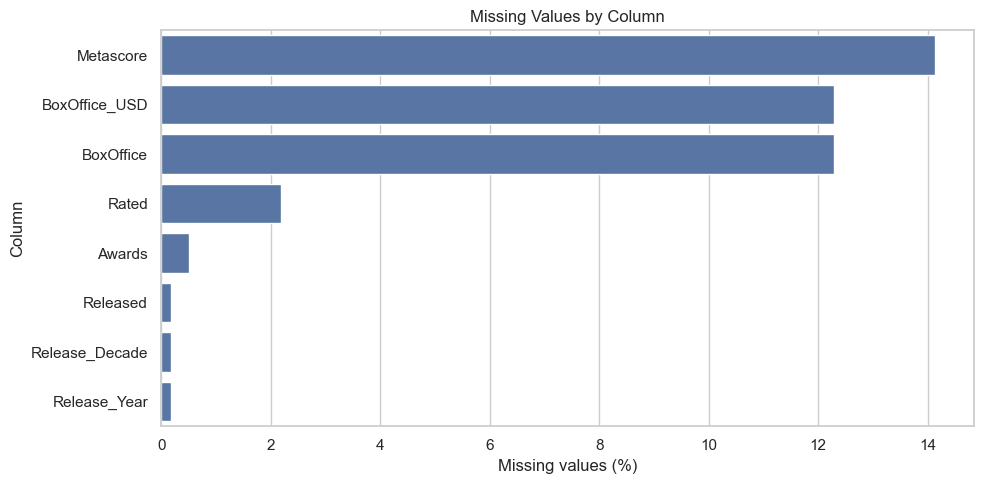

In [6]:
missing = quality[quality["missing_count"] > 0].sort_values("missing_percent", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing["missing_percent"], y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


## 8. Visualization 2 — Movies by Year

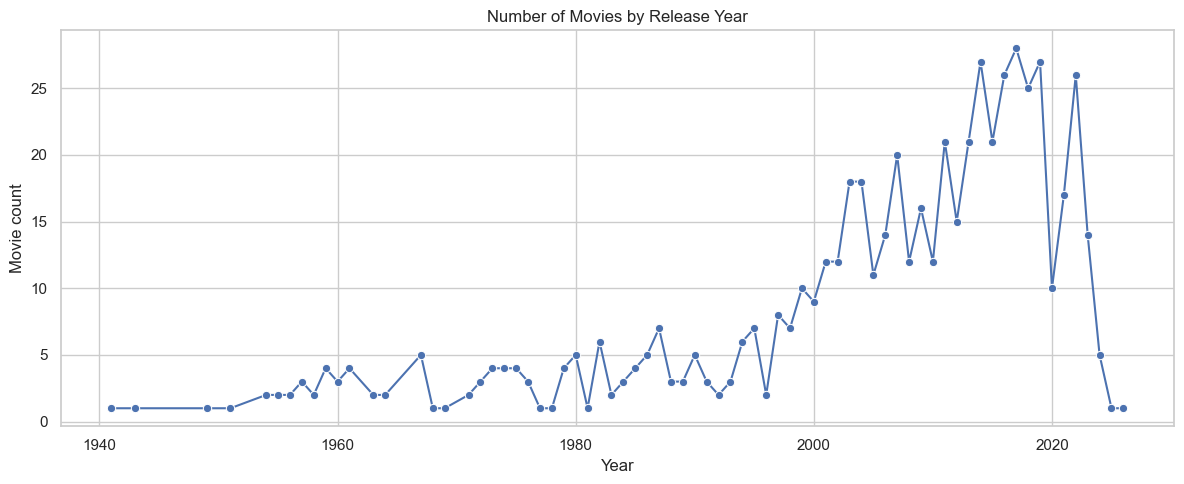

In [7]:
year_counts = (
    df.dropna(subset=["Analysis_Year"])
      .groupby("Analysis_Year")
      .size()
      .sort_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
plt.title("Number of Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Movie count")
plt.tight_layout()
plt.show()


## 9. Visualization 3 — Top Genres

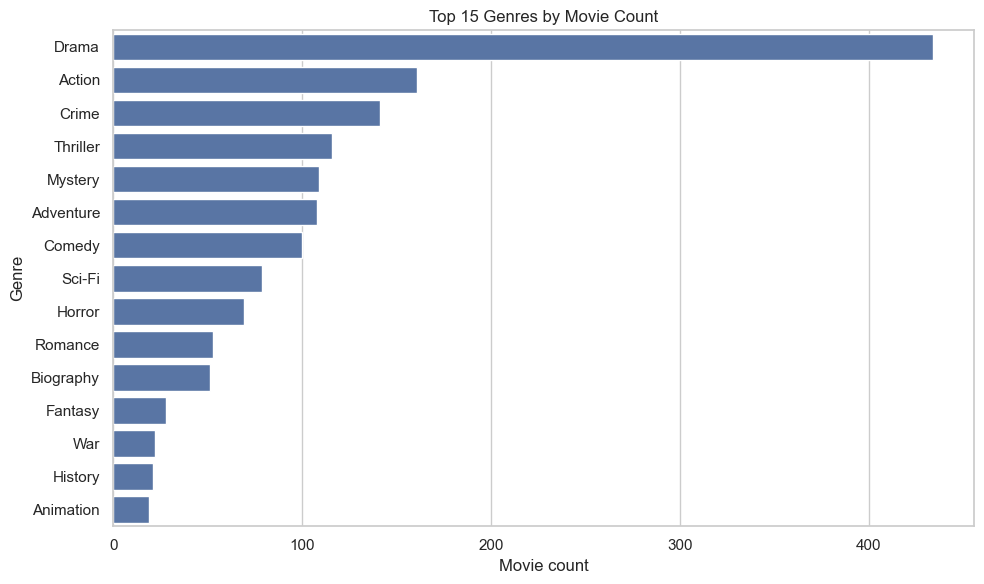

In [8]:
genre_counts = (
    df["Genre"].dropna().str.split(",").explode().str.strip()
      .value_counts().head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 15 Genres by Movie Count")
plt.xlabel("Movie count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


## 10. Visualization 4 — IMDb Rating Distribution

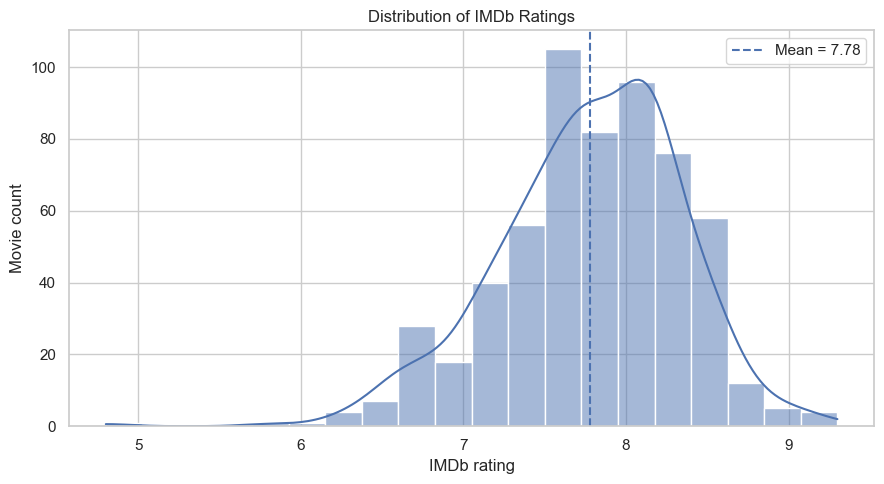

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(df["imdbRating"].dropna(), bins=20, kde=True)
plt.axvline(df["imdbRating"].mean(), linestyle="--", label=f"Mean = {df['imdbRating'].mean():.2f}")
plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb rating")
plt.ylabel("Movie count")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Visualization 5 — Runtime Distribution

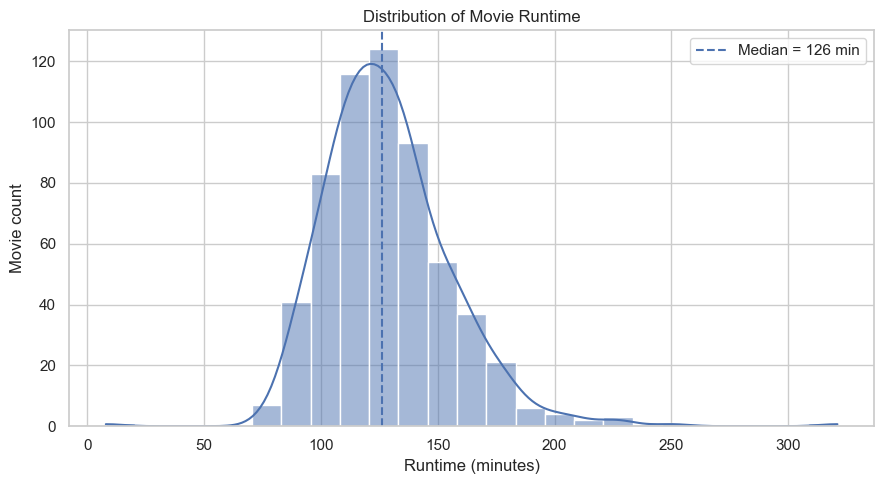

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Runtime(in minutes)"].dropna(), bins=25, kde=True)
plt.axvline(df["Runtime(in minutes)"].median(), linestyle="--",
            label=f"Median = {df['Runtime(in minutes)'].median():.0f} min")
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Movie count")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Visualization 6 — Runtime Outliers

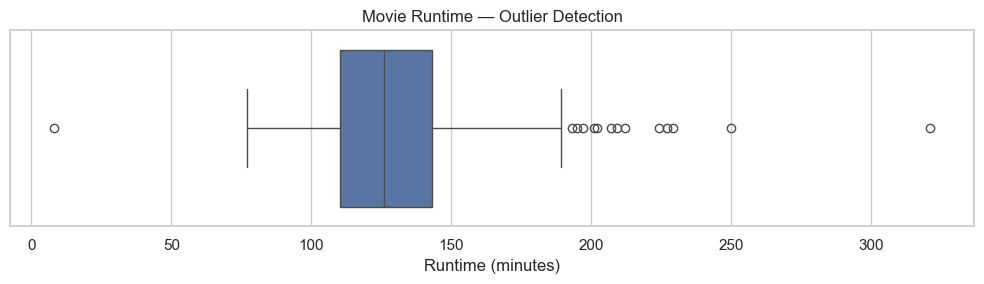

In [11]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["Runtime(in minutes)"])
plt.title("Movie Runtime — Outlier Detection")
plt.xlabel("Runtime (minutes)")
plt.tight_layout()
plt.show()


## 13. Visualization 7 — IMDb Rating by Runtime Category

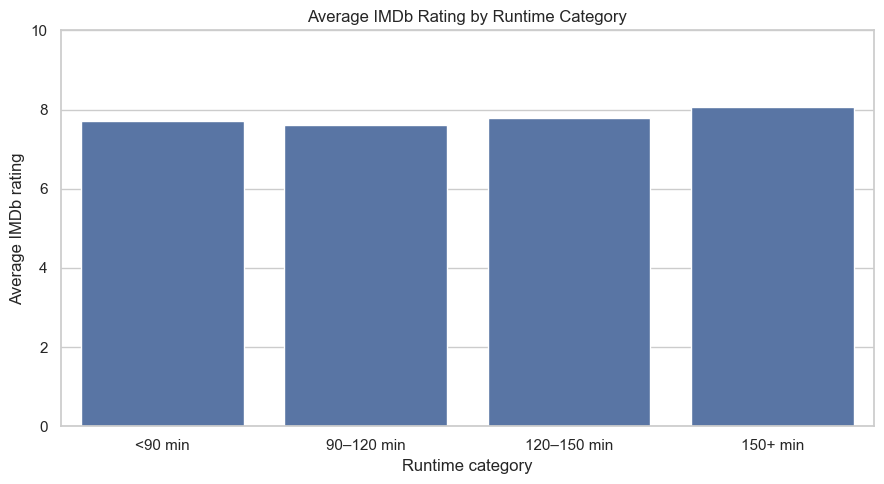

In [12]:
runtime_rating = (
    df.dropna(subset=["Runtime_Category", "imdbRating"])
      .groupby("Runtime_Category", observed=True)["imdbRating"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=runtime_rating, x="Runtime_Category", y="imdbRating")
plt.title("Average IMDb Rating by Runtime Category")
plt.xlabel("Runtime category")
plt.ylabel("Average IMDb rating")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


## 14. Visualization 8 — Runtime vs IMDb Rating

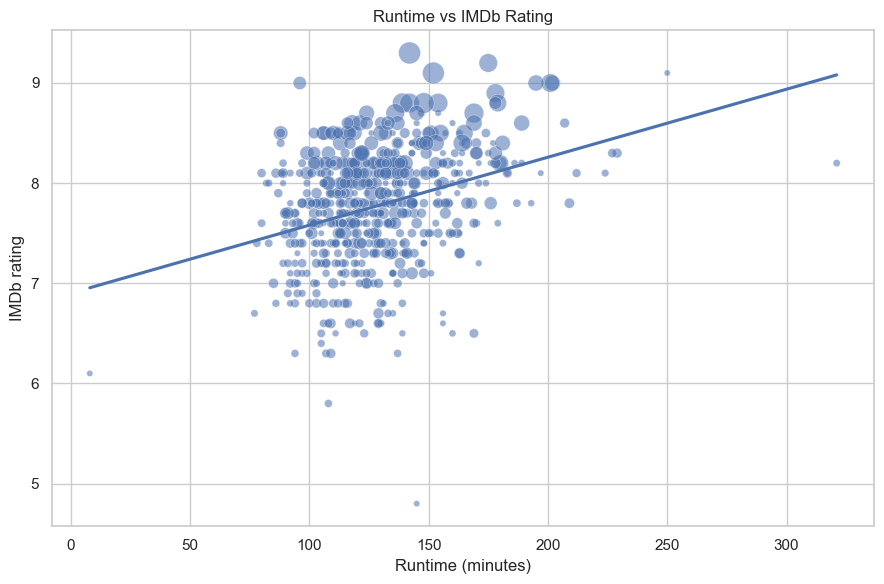

Pearson correlation: 0.329


In [13]:
plot_df = df.dropna(subset=["Runtime(in minutes)", "imdbRating"])

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="Runtime(in minutes)",
    y="imdbRating",
    size="imdbVotes",
    sizes=(20, 250),
    alpha=0.55,
    legend=False
)
sns.regplot(
    data=plot_df,
    x="Runtime(in minutes)",
    y="imdbRating",
    scatter=False,
    ci=None
)
plt.title("Runtime vs IMDb Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDb rating")
plt.tight_layout()
plt.show()

print("Pearson correlation:", plot_df["Runtime(in minutes)"].corr(plot_df["imdbRating"]).round(3))


## 15. Visualization 9 — IMDb Votes vs IMDb Rating

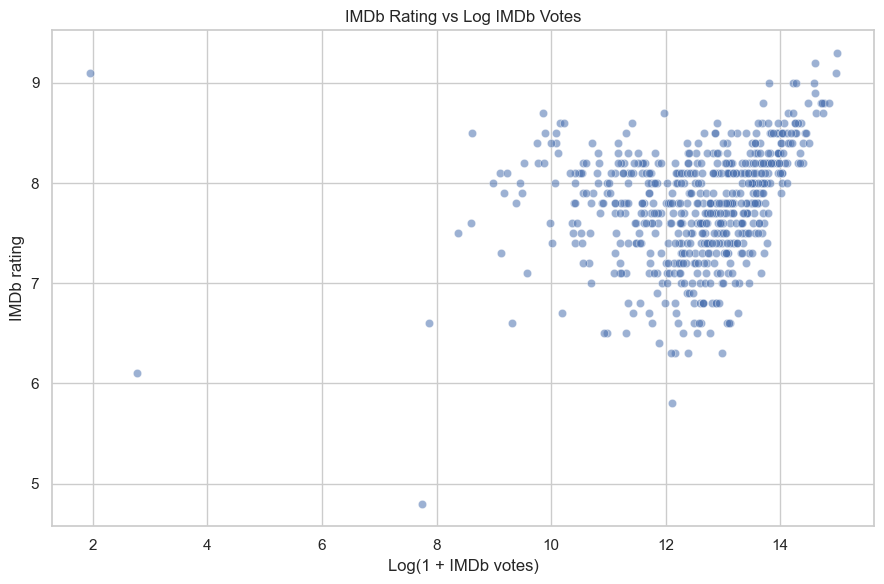

Correlation: 0.466


In [14]:
plot_df = df.dropna(subset=["imdbVotes", "imdbRating"]).copy()
plot_df["log_imdbVotes"] = np.log1p(plot_df["imdbVotes"])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="log_imdbVotes", y="imdbRating", alpha=0.55)
plt.title("IMDb Rating vs Log IMDb Votes")
plt.xlabel("Log(1 + IMDb votes)")
plt.ylabel("IMDb rating")
plt.tight_layout()
plt.show()

print("Correlation:", plot_df["imdbVotes"].corr(plot_df["imdbRating"]).round(3))


## 16. Visualization 10 — IMDb Rating vs Metascore

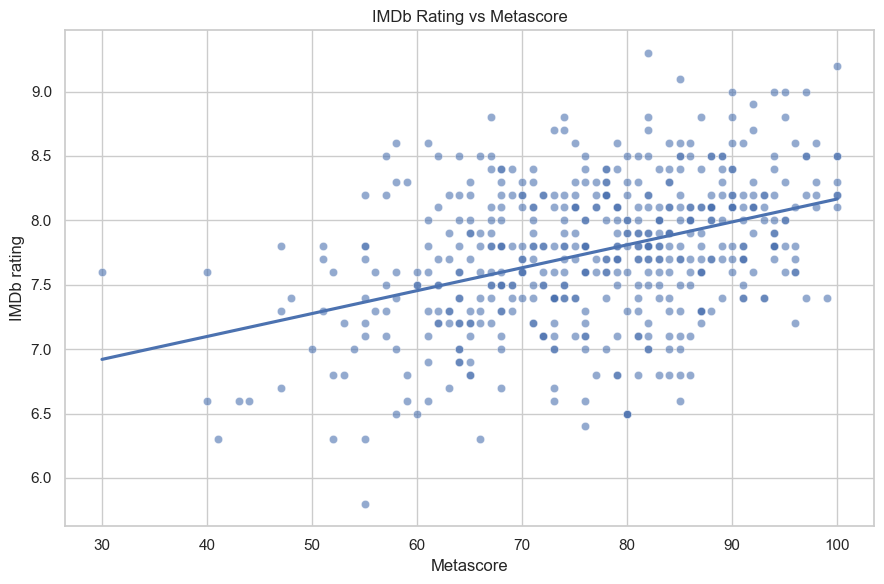

Correlation: 0.399


In [15]:
plot_df = df.dropna(subset=["Metascore", "imdbRating"])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="Metascore", y="imdbRating", alpha=0.6)
sns.regplot(data=plot_df, x="Metascore", y="imdbRating", scatter=False, ci=None)
plt.title("IMDb Rating vs Metascore")
plt.xlabel("Metascore")
plt.ylabel("IMDb rating")
plt.tight_layout()
plt.show()

print("Correlation:", plot_df["Metascore"].corr(plot_df["imdbRating"]).round(3))


## 17. Visualization 11 — IMDb Rating Distribution by Content Rating

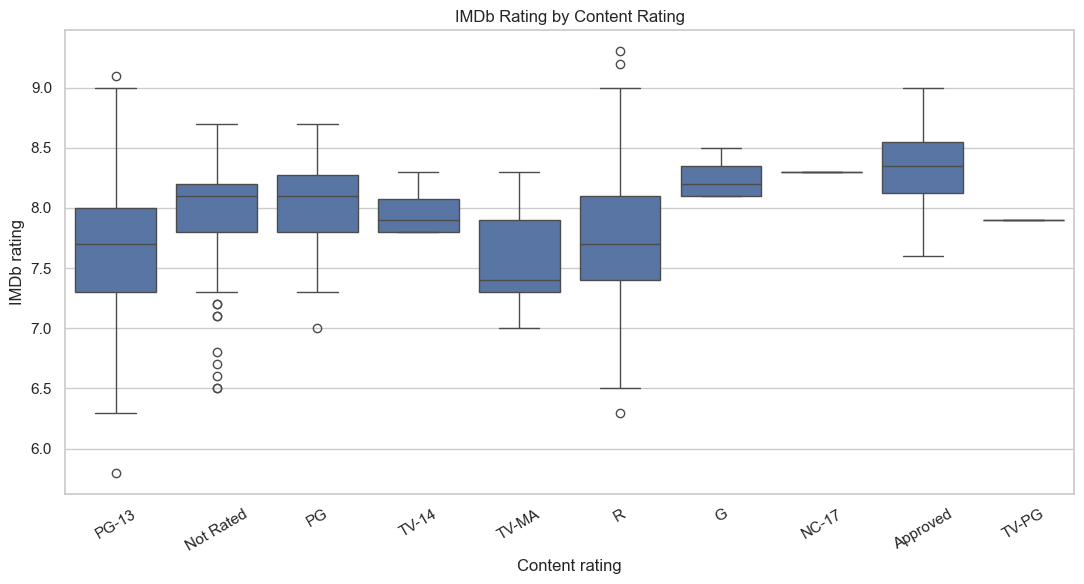

In [16]:
rated_counts = df["Rated"].value_counts().head(10).index
plot_df = df[df["Rated"].isin(rated_counts)].dropna(subset=["imdbRating"])

plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_df, x="Rated", y="imdbRating")
plt.title("IMDb Rating by Content Rating")
plt.xlabel("Content rating")
plt.ylabel("IMDb rating")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 18. Visualization 12 — Top Countries

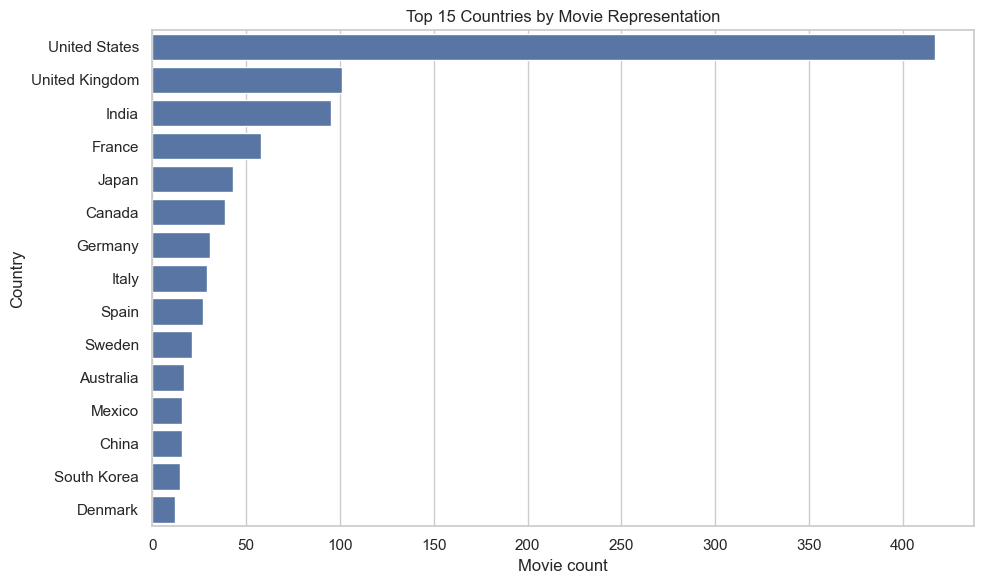

In [17]:
country_counts = (
    df["Country"].dropna().str.split(",").explode().str.strip()
      .value_counts().head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 15 Countries by Movie Representation")
plt.xlabel("Movie count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 19. Visualization 13 — Top Languages

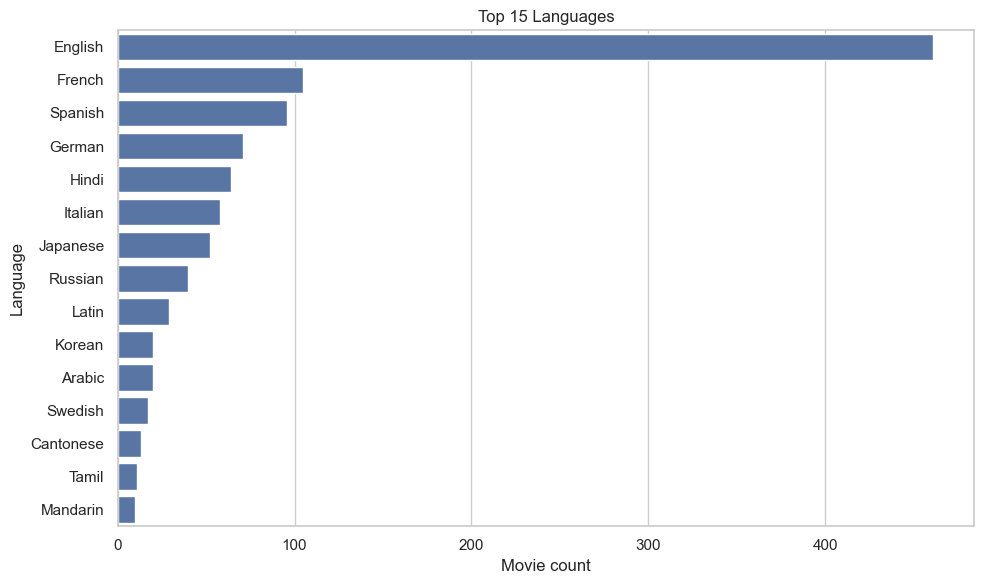

In [18]:
language_counts = (
    df["Language"].dropna().str.split(",").explode().str.strip()
      .value_counts().head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=language_counts.values, y=language_counts.index)
plt.title("Top 15 Languages")
plt.xlabel("Movie count")
plt.ylabel("Language")
plt.tight_layout()
plt.show()


## 20. Visualization 14 — Most Frequent Directors

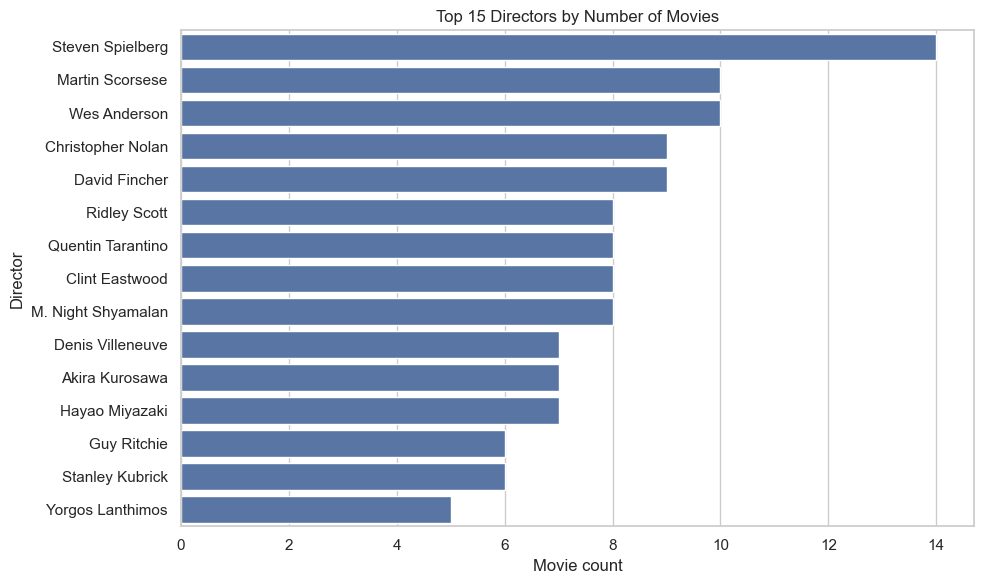

In [19]:
director_counts = df["Director"].dropna().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=director_counts.values, y=director_counts.index)
plt.title("Top 15 Directors by Number of Movies")
plt.xlabel("Movie count")
plt.ylabel("Director")
plt.tight_layout()
plt.show()


## 21. Visualization 15 — Best-Reviewed Directors with a Minimum Sample

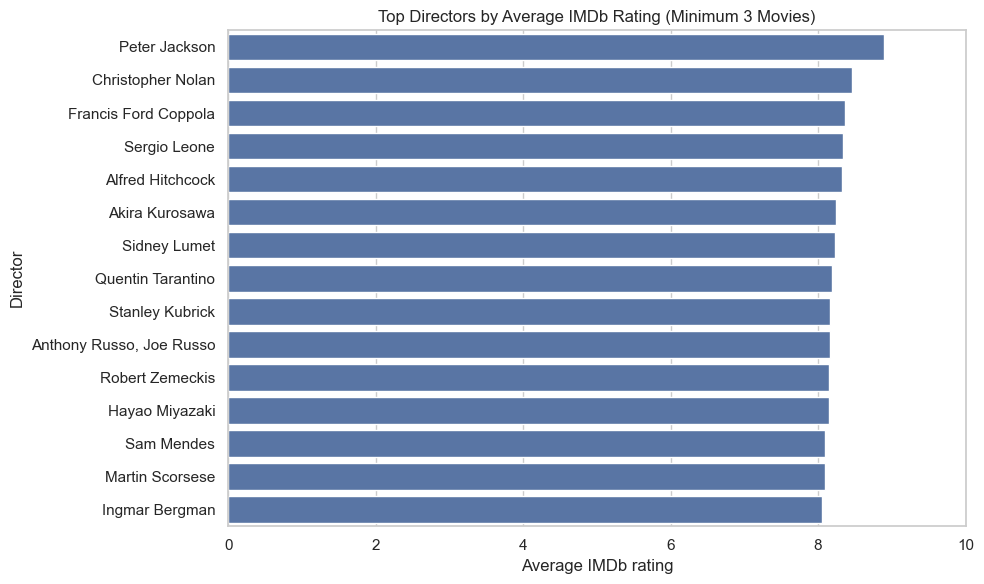

,Director,movies,avg_rating
0,Peter Jackson,3,8.90
1,Christopher Nolan,9,8.46
2,Francis Ford Coppola,5,8.36
3,Sergio Leone,5,8.34
4,Alfred Hitchcock,5,8.32
5,Akira Kurosawa,7,8.24
6,Sidney Lumet,3,8.23
7,Quentin Tarantino,8,8.19
8,Stanley Kubrick,6,8.17
9,"Anthony Russo, Joe Russo",3,8.17


In [20]:
director_stats = (
    df.dropna(subset=["Director", "imdbRating"])
      .groupby("Director")
      .agg(
          movies=("Title", "count"),
          avg_rating=("imdbRating", "mean")
      )
      .query("movies >= 3")
      .sort_values(["avg_rating", "movies"], ascending=[False, False])
      .head(15)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=director_stats, x="avg_rating", y="Director")
plt.title("Top Directors by Average IMDb Rating (Minimum 3 Movies)")
plt.xlabel("Average IMDb rating")
plt.ylabel("Director")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

display(director_stats)


## 22. Visualization 16 — Average IMDb Rating by Decade

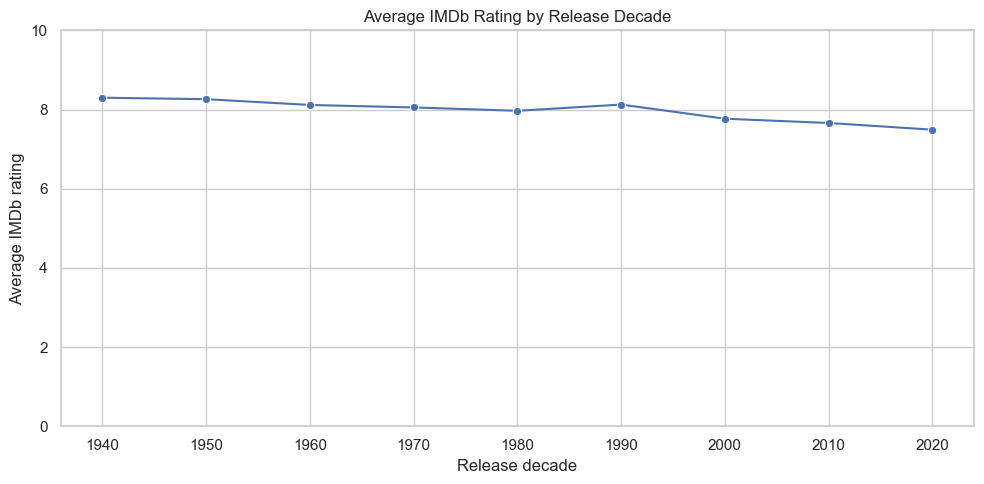

In [21]:
decade_stats = (
    df.dropna(subset=["Release_Decade", "imdbRating"])
      .groupby("Release_Decade")
      .agg(
          movies=("Title", "count"),
          avg_rating=("imdbRating", "mean")
      )
      .reset_index()
      .sort_values("Release_Decade")
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=decade_stats, x="Release_Decade", y="avg_rating", marker="o")
plt.title("Average IMDb Rating by Release Decade")
plt.xlabel("Release decade")
plt.ylabel("Average IMDb rating")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


## 23. Visualization 17 — Movie Volume by Decade

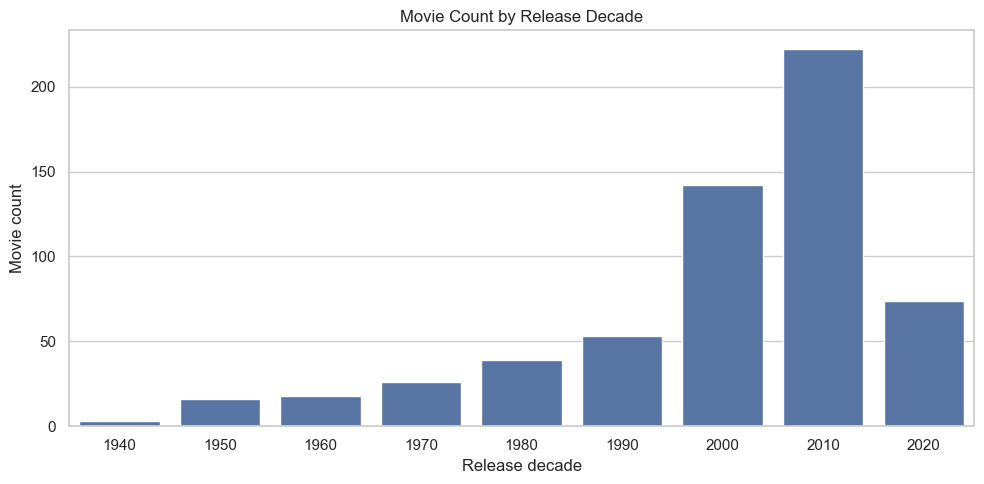

In [22]:
decade_counts = (
    df.dropna(subset=["Release_Decade"])
      .groupby("Release_Decade")
      .size()
      .reset_index(name="movie_count")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=decade_counts, x="Release_Decade", y="movie_count")
plt.title("Movie Count by Release Decade")
plt.xlabel("Release decade")
plt.ylabel("Movie count")
plt.tight_layout()
plt.show()


## 24. Visualization 18 — BoxOffice vs IMDb Rating

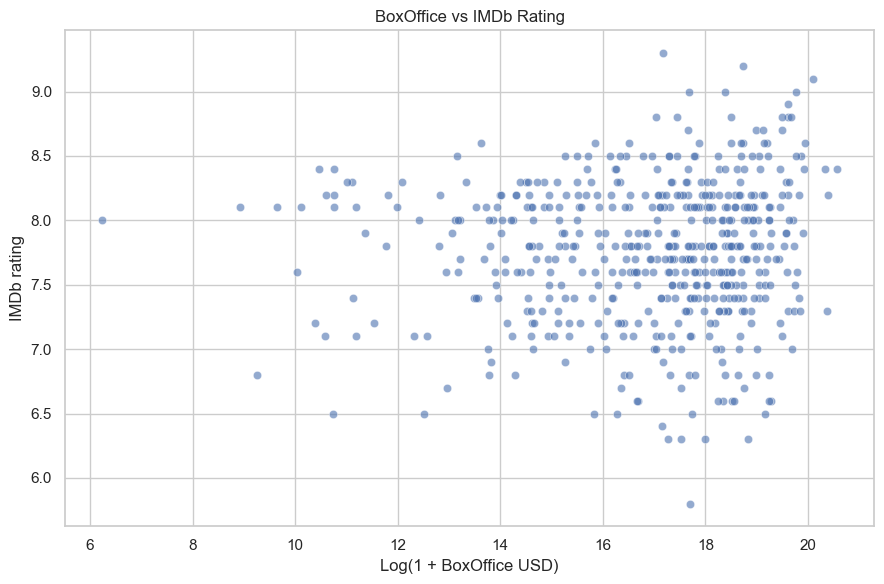

Correlation: 0.148


In [23]:
plot_df = df.dropna(subset=["BoxOffice_USD", "imdbRating"]).copy()
plot_df["log_boxoffice"] = np.log1p(plot_df["BoxOffice_USD"])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="log_boxoffice", y="imdbRating", alpha=0.6)
plt.title("BoxOffice vs IMDb Rating")
plt.xlabel("Log(1 + BoxOffice USD)")
plt.ylabel("IMDb rating")
plt.tight_layout()
plt.show()

if len(plot_df) > 1:
    print("Correlation:", plot_df["BoxOffice_USD"].corr(plot_df["imdbRating"]).round(3))


## 25. Ranking Analysis — Highest-Rated Movies

A raw IMDb ranking can favor movies with very few votes. To make the ranking more defensible, apply a minimum vote threshold and show the threshold explicitly.


In [24]:
MIN_VOTES = 10000

top_rated = (
    df.dropna(subset=["Title", "imdbRating", "imdbVotes"])
      .query("imdbVotes >= @MIN_VOTES")
      .sort_values(["imdbRating", "imdbVotes"], ascending=[False, False])
      [["Title", "Year", "Genre", "imdbRating", "imdbVotes"]]
      .head(20)
)

display(top_rated)


,Title,Year,Genre,imdbRating,imdbVotes
89,The Shawshank Redemption,1994,Drama,9.30,3221305
90,The Godfather,1972,"Crime, Drama",9.20,2222804
92,The Dark Knight,2008,"Action, Crime, Drama",9.10,3161907
121,The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.00,2161991
220,Schindler's List,1994,"Biography, Drama, History",9.00,1582378
91,The Godfather Part II,1974,"Crime, Drama",9.00,1492120
210,12 Angry Men,1957,"Crime, Drama",9.00,981488
119,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure, Drama, Fantasy",8.90,2203785
96,Inception,2010,"Action, Adventure, Sci-Fi",8.80,2811614
94,Fight Club,1999,"Crime, Drama, Thriller",8.80,2601857


## 26. Commercial Analysis — Highest BoxOffice Movies

In [25]:
top_boxoffice = (
    df.dropna(subset=["Title", "BoxOffice_USD"])
      .sort_values("BoxOffice_USD", ascending=False)
      [["Title", "Year", "Genre", "imdbRating", "BoxOffice_USD"]]
      .head(15)
)

display(top_boxoffice)


,Title,Year,Genre,imdbRating,BoxOffice_USD
449,Avengers: Endgame,2019,"Action, Adventure, Sci-Fi",8.40,858373000
476,Top Gun: Maverick,2022,"Action, Drama",8.20,721996984
454,Black Panther,2018,"Action, Adventure, Sci-Fi",7.30,700426566
448,Avengers: Infinity War,2018,"Action, Adventure, Sci-Fi",8.40,678815482
92,The Dark Knight,2008,"Action, Crime, Drama",9.10,534987076
122,Star Wars: Episode IV - A New Hope,1977,"Action, Adventure, Fantasy",8.60,460998507
433,The Dark Knight Rises,2012,"Action, Crime, Drama",8.40,448149584
242,E.T. the Extra-Terrestrial,1982,"Adventure, Family, Sci-Fi",7.90,439454989
116,The Lion King,1994,"Animation, Adventure, Drama",8.50,424979720
457,Wonder Woman,2017,"Action, Adventure, Fantasy",7.30,412845172


## 27. Genre-Level Performance

Because the `Genre` field contains multiple comma-separated genres, explode it before calculating genre-level statistics. This avoids treating combinations such as `"Comedy, Drama"` as a completely separate genre.


In [26]:
genre_performance = (
    df.dropna(subset=["Genre", "imdbRating"])
      .assign(Genre=df["Genre"].str.split(","))
      .explode("Genre")
)

genre_performance["Genre"] = genre_performance["Genre"].str.strip()

genre_summary = (
    genre_performance.groupby("Genre")
    .agg(
        movies=("Title", "count"),
        avg_rating=("imdbRating", "mean"),
        median_rating=("imdbRating", "median")
    )
    .query("movies >= 5")
    .sort_values(["avg_rating", "movies"], ascending=[False, False])
)

display(genre_summary.head(15))


,movies,avg_rating,median_rating
Genre,,,
Western,8,8.24,8.20
War,22,8.16,8.20
Family,8,8.11,8.05
Musical,8,8.09,8.10
Animation,19,8.08,8.00
Music,6,8.07,7.95
Sport,14,7.94,8.10
Biography,51,7.93,8.00
Crime,141,7.90,7.90


## 28. Automated Insight Summary

The following section calculates the main findings directly from the cleaned dataset rather than hard-coding numbers. This makes the notebook safer to reuse if the CSV is updated.


In [27]:
def safe_round(value, digits=2):
    return round(float(value), digits) if pd.notna(value) else np.nan

print("KEY INSIGHTS")
print("=" * 70)

print(f"• Dataset size after cleaning: {len(df):,} movies.")

if "imdbRating" in df:
    print(
        f"• Average IMDb rating: {safe_round(df['imdbRating'].mean())}; "
        f"median: {safe_round(df['imdbRating'].median())}."
    )

if "Runtime(in minutes)" in df:
    print(
        f"• Median runtime: {safe_round(df['Runtime(in minutes)'].median(), 0):.0f} minutes; "
        f"maximum: {safe_round(df['Runtime(in minutes)'].max(), 0):.0f} minutes."
    )

if not genre_counts.empty:
    print(f"• Most represented genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} records).")

if not director_counts.empty:
    print(f"• Most frequently represented director: {director_counts.index[0]} ({director_counts.iloc[0]:,} movies).")

if not country_counts.empty:
    print(f"• Most represented country: {country_counts.index[0]} ({country_counts.iloc[0]:,} records).")

if not language_counts.empty:
    print(f"• Most represented language: {language_counts.index[0]} ({language_counts.iloc[0]:,} records).")

if len(plot_df) > 1:
    print("• Commercial/rating relationship is shown using a log-scaled BoxOffice axis because BoxOffice is highly skewed.")

print("• Missing Metascore and BoxOffice values should be interpreted as unavailable data, not zero performance.")


KEY INSIGHTS
• Dataset size after cleaning: 594 movies.
• Average IMDb rating: 7.78; median: 7.8.
• Median runtime: 126 minutes; maximum: 321 minutes.
• Most represented genre: Drama (434 records).
• Most frequently represented director: Steven Spielberg (14 movies).
• Most represented country: United States (417 records).
• Most represented language: English (461 records).
• Commercial/rating relationship is shown using a log-scaled BoxOffice axis because BoxOffice is highly skewed.
• Missing Metascore and BoxOffice values should be interpreted as unavailable data, not zero performance.


## 29. Business / Analytical Interpretation

### What this analysis can tell a movie-platform stakeholder

**Content strategy**
- Genre frequency shows where the dataset is concentrated.
- Genre-level rating comparisons help identify categories associated with stronger audience reception.

**Audience engagement**
- IMDb votes provide a proxy for audience participation.
- Comparing votes with ratings helps distinguish highly rated movies from movies with broad audience engagement.

**Critical vs audience response**
- IMDb Rating and Metascore measure different aspects of reception.
- Their relationship can reveal whether critic and audience opinions generally move together.

**Catalog planning**
- Release-year and decade trends show how the analyzed catalog is distributed over time.
- Runtime analysis can support content segmentation and recommendation strategies.

**Commercial performance**
- BoxOffice analysis provides a separate dimension from ratings.
- A commercially successful movie is not automatically the highest-rated movie, so the two metrics should be analyzed independently.


## 30. Data-Quality Findings and Limitations

1. The original notebook contained a **schema mismatch**: movie columns such as `Title` were followed by roller-coaster columns such as `Coaster_Name`. This is why the original workflow eventually produced `KeyError: "['Title'] not in index"`. fileciteturn5file0L643-L671
2. Missing values exist in several important fields. The original notebook recorded 84 missing Metascore values and 73 missing BoxOffice values. fileciteturn5file0L747-L768
3. BoxOffice is available only for part of the dataset, so BoxOffice conclusions describe the available subset rather than the entire movie catalog.
4. Multi-valued fields such as Genre, Country, and Language are split into individual categories for category-level analysis.
5. Correlation does not imply causation. For example, a relationship between runtime and rating does not prove that changing runtime would change audience ratings.
6. This is an EDA project, not a predictive model. The purpose is to understand data quality, distributions, relationships, and patterns before modeling.


## 31. Final Conclusion

This project demonstrates a complete EDA workflow on movie data: **data loading → data understanding → cleaning → feature engineering → univariate analysis → bivariate analysis → multivariate relationships → ranking → insight generation → business interpretation**.

The rewritten notebook is designed to be interview-ready because every visualization answers a specific analytical question rather than existing only for presentation. The most important improvement over the original notebook is that the analysis now uses **one consistent movie dataset from start to finish**, avoiding the previous movie/roller-coaster schema conflict.

### Interview takeaway

If asked *“What did you do in this project?”*, a strong answer is:

> I performed an end-to-end exploratory analysis of an IMDb movie dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn. I first audited the data for missing values, duplicates, incorrect data types, and inconsistent formats. I then engineered release-year, decade, runtime-category, vote, and BoxOffice features and analyzed genre, country, language, director, rating, runtime, audience votes, Metascore, and commercial performance. Finally, I converted the findings into business-oriented insights while clearly documenting data limitations.


## 32. Reproducibility Checklist

In [ ]:
# Final checks before sharing the notebook
required_columns = ["Title", "Year", "Genre", "Director", "imdbRating", "imdbVotes"]

missing_required = [c for c in required_columns if c not in df.columns]

print("Required columns missing:", missing_required)
print("Final rows:", len(df))
print("Final columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Notebook-ready:", len(missing_required) == 0 and df.duplicated().sum() == 0)
